# Predictive Analytics - Prediksi Rating Ulasan Pelanggan pada Penjualan Retail Fashion

##### Nama: Arya Gunawan

## Deskripsi Proyek

Proyek ini bertujuan untuk menerapkan pendekatan analitik prediktif dalam mempelajari pola dan perilaku pelanggan pada penjualan produk fashion. Data yang digunakan berasal dari 3.400 transaksi penjualan ritel yang memuat informasi penting seperti jenis barang yang dibeli, jumlah pembayaran, metode pembayaran, tanggal pembelian, serta penilaian atau rating dari pelanggan.

Fokus utama proyek ini adalah membangun model yang mampu memprediksi nilai review rating pelanggan berdasarkan informasi transaksi yang tersedia. Dengan memahami hubungan antara variabel-variabel tersebut, diharapkan proyek ini dapat memberikan gambaran yang lebih dalam mengenai faktor-faktor yang memengaruhi kepuasan pelanggan terhadap produk fashion yang mereka beli.

Hasil dari analisis ini dapat digunakan untuk mendukung pengambilan keputusan bisnis, seperti peningkatan layanan, strategi produk, maupun penyesuaian metode pembayaran yang lebih sesuai dengan preferensi pelanggan.

## Data Understanding

Menyiapkan dan memuat library Python yang dibutuhkan untuk mendukung seluruh proses dalam proyek ini.

In [1]:
# Impor pustaka standar
import matplotlib.pyplot as plt  # Untuk visualisasi
import numpy as np  # Untuk komputasi numerik
import pandas as pd  # Untuk manipulasi data
import seaborn as sns  # Untuk visualisasi statistik

# Impor modul dari scikit-learn
from sklearn.decomposition import PCA  # Analisis komponen utama
from sklearn.ensemble import (
    AdaBoostRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor
)  # Model ensemble
from sklearn.metrics import mean_squared_error  # Metrik evaluasi
from sklearn.model_selection import train_test_split  # Pembagian dataset
from sklearn.neighbors import KNeighborsRegressor  # Model KNN
from sklearn.preprocessing import StandardScaler  # Standarisasi fitur

### Data Loading

Membaca dan Menampilkan Dataset Fashion Retail Sales

*Dataset diambil dari https://www.kaggle.com/datasets/atharvasoundankar/fashion-retail-sales*

In [2]:
# Load the dataset
url = 'https://raw.githubusercontent.com/Aryaagunawan/mlt1/master/Fashion_Retail_Sales.csv'
df = pd.read_csv(url)

# Tampilkan dataframe
df

,Customer Reference ID,Item Purchased,Purchase Amount (USD),Date Purchase,Review Rating,Payment Method
0,4018,Handbag,4619.0,05-02-2023,NaN,Credit Card
1,4115,Tunic,2456.0,11-07-2023,2.0,Credit Card
2,4019,Tank Top,2102.0,23-03-2023,4.1,Cash
3,4097,Leggings,3126.0,15-03-2023,3.2,Cash
4,3997,Wallet,3003.0,27-11-2022,4.7,Cash
...,...,...,...,...,...,...
3395,4118,Shorts,37.0,09-07-2023,2.7,Cash
3396,4056,Slippers,176.0,16-03-2023,2.5,Cash
3397,3991,Onesie,NaN,03-10-2022,2.4,Credit Card
3398,4042,Sandals,128.0,01-01-2023,1.8,Cash


Output kode di atas memberikan informasi sebagai berikut:

- Jumlah data: 3400 baris × 6 kolom
- Terdapat 6 kolom yaitu: Customer Reference ID, Item Purchased, Purchase Amount (USD), Date Purchase, Review Rating, Payment Method.

### Exploratory Data Analysis - Deskripsi Variabel

Berdasarkan informasi dari sumber dataset berikut adalah penjelasan untuk masing-masing kolom :

  - **Customer Reference ID**: ID unik tiap pelanggan
  - **Item Purchased**: Nama produk yang dibeli
  - **Purchase Amount (USD)**: Jumlah pembelian (dalam USD)
  - **Date Purchase**: Tanggal pembelian (format: DD-MM-YYYY)
  - **Review Rating**: Rating ulasan dari pelanggan (nilai bisa hilang)
  - **Payment Method**: Metode pembayaran (Cash atau Credit Card)

Informasi pada dataset

In [3]:
# mengecek informasi pada dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3400 entries, 0 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3400 non-null   int64  
 1   Item Purchased         3400 non-null   object 
 2   Purchase Amount (USD)  2750 non-null   float64
 3   Date Purchase          3400 non-null   object 
 4   Review Rating          3076 non-null   float64
 5   Payment Method         3400 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 159.5+ KB


Dari output `df.info()`, diperoleh informasi sebagai berikut:

- Terdapat **3 kolom dengan tipe data `object`**, yaitu:
  - `Item Purchased`
  - `Date Purchase`
  - `Payment Method`  
  Ketiga kolom ini merupakan **fitur kategorikal** (non-numerik).

- Terdapat **2 kolom numerik bertipe `float64`**, yaitu:
  - `Purchase Amount (USD)`
  - `Review Rating`  
  Kolom-kolom ini menyimpan data numerik yang dapat dianalisis secara statistik.

- Terdapat **1 kolom numerik bertipe `int64`**, yaitu:
  - `Customer Reference ID`  
  Kolom ini berisi ID unik pelanggan dan bukan merupakan fitur prediktif utama.

- **Missing Values**:
  - `Purchase Amount (USD)` memiliki **650 data kosong**.
  - `Review Rating` memiliki **324 data kosong**.

Mengecek deskripsi statistik data

In [4]:
df.describe()

,Customer Reference ID,Purchase Amount (USD),Review Rating
count,3400.000000,2750.000000,3076.000000
mean,4039.660588,156.709818,2.999057
std,48.122583,419.536669,1.156505
min,3957.000000,10.000000,1.000000
25%,3997.000000,57.000000,2.000000
50%,4040.000000,110.000000,3.000000
75%,4081.000000,155.750000,4.000000
max,4122.000000,4932.000000,5.000000


Dari hasil `df.describe()`, diperoleh informasi sebagai berikut:

- **Customer Reference ID**:
  - Jumlah data: 3400
  - Rentang ID: 3957 hingga 4122
  - Median: 4040
  - Penyebaran data cukup merata berdasarkan nilai standar deviasi (±48)

- **Purchase Amount (USD)**:
  - Jumlah data valid: 2750 (terdapat 650 nilai kosong)
  - Rata-rata pembelian: $156.71
  - Nilai minimum: $10.00
  - Nilai maksimum: $4932.00
  - Median (50%): $110.00
  - Nilai Q1 (25%): $57.00, Q3 (75%): $155.75
  - Standar deviasi yang tinggi ($419.54) menunjukkan variasi besar antar pembelian

- **Review Rating**:
  - Jumlah data valid: 3076 (terdapat 324 nilai kosong)
  - Rata-rata rating: 2.999 (sekitar 3.0 dari skala 1–5)
  - Nilai minimum: 1.0
  - Nilai maksimum: 5.0
  - Median (50%): 3.0
  - Sebagian besar rating berada antara 2.0 hingga 4.0

### Exploratory Data Analysis - Menangani Missing Value dan Outliers

Jumlah missing value pada setiap kolom

In [5]:
# Cek jumlah missing value pada setiap kolom
df.isnull().sum()

,0
Customer Reference ID,0
Item Purchased,0
Purchase Amount (USD),650
Date Purchase,0
Review Rating,324
Payment Method,0


insight:

- Kolom Purchase Amount (USD) memiliki 650 missing values (nilai kosong)

- Kolom Review Rating memiliki 324 missing values

- Kolom lainnya sudah lengkap tanpa missing values

Menangani missing value dengan median

In [6]:
# Imputasi missing value dengan median
median_purchase = df['Purchase Amount (USD)'].median()
df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(median_purchase)

Menghapus baris dengan nilai kosong pada kolom Review Rating

In [7]:
# Drop baris dengan target yang kosong
df.dropna(subset=['Review Rating'], inplace=True)

Analisis outlier menggunakan boxplot untuk Purchase Amount dan Review Rating

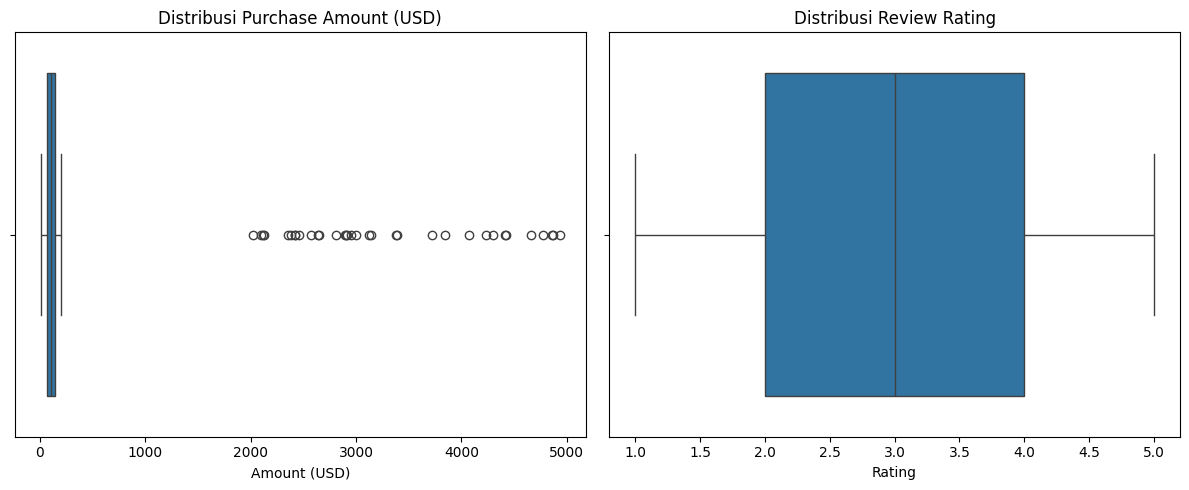

In [8]:
# Visualisasi boxplot untuk mendeteksi outlier
plt.figure(figsize=(12, 5))

# Boxplot Purchase Amount
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Purchase Amount (USD)'])
plt.title('Distribusi Purchase Amount (USD)')
plt.xlabel('Amount (USD)')

# Boxplot Review Rating
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Review Rating'])
plt.title('Distribusi Review Rating')
plt.xlabel('Rating')

plt.tight_layout()
plt.show()

Insight:

- Variabel amount memerlukan treatment khusus untuk outlier dan skewness

- Variabel rating relatif lebih stabil secara statistik

- Outlier di kedua variabel perlu dicek konsistensinya dengan business context

Deteksi dan penghapusan outlier menggunakan metode IQR pada Purchase Amount

In [9]:
# Hitung batas bawah dan atas untuk outlier dengan metode IQR
Q1 = df['Purchase Amount (USD)'].quantile(0.25)  # Kuartil pertama
Q3 = df['Purchase Amount (USD)'].quantile(0.75)  # Kuartil ketiga
IQR = Q3 - Q1                                   # Interquartile Range

# Tentukan batas outlier
lower_bound = Q1 - 1.5 * IQR  # Batas bawah
upper_bound = Q3 + 1.5 * IQR  # Batas atas

# Filter dataframe untuk menghilangkan outlier
df = df[
    (df['Purchase Amount (USD)'] >= lower_bound) &
    (df['Purchase Amount (USD)'] <= upper_bound)
]

In [10]:
# ANALISIS STRUKTUR DATA
print("INFORMASI DATA (df.info())")
df.info()
# STATISTIK DESKRIPTIF
print("STATISTIK DESKRIPTIF")
print(df.describe())

INFORMASI DATA (df.info())
<class 'pandas.core.frame.DataFrame'>
Index: 3042 entries, 43 to 3399
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Reference ID  3042 non-null   int64  
 1   Item Purchased         3042 non-null   object 
 2   Purchase Amount (USD)  3042 non-null   float64
 3   Date Purchase          3042 non-null   object 
 4   Review Rating          3042 non-null   float64
 5   Payment Method         3042 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 166.4+ KB
STATISTIK DESKRIPTIF
       Customer Reference ID  Purchase Amount (USD)  Review Rating
count            3042.000000            3042.000000    3042.000000
mean             4039.911900             106.838922       2.994543
std                48.035311              49.723078       1.154963
min              3957.000000              10.000000       1.000000
25%              3998.000000       

## Univariate Analysis

Analisis Distribusi Frekuensi Review Rating

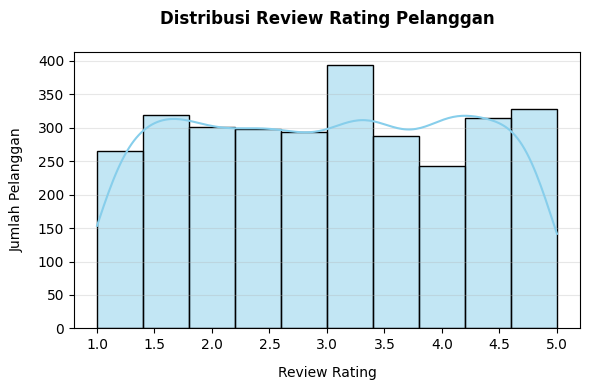

In [11]:
# ANALISIS UNIVARIAT - DISTRIBUSI REVIEW RATING
plt.figure(figsize=(6, 4))
sns.histplot(
    data=df,
    x='Review Rating',
    bins=10,
    kde=True,
    color='skyblue',
    edgecolor='black'
)

# Formatting plot
plt.title('Distribusi Review Rating Pelanggan', pad=20, fontweight='bold')
plt.xlabel('Review Rating', labelpad=10)
plt.ylabel('Jumlah Pelanggan', labelpad=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Insight:

-  Dominasi Rating Tinggi
Mayoritas pelanggan memberi rating 4.0-5.0 (terlihat dari puncak histogram di kanan).

- Anomali Rating Rendah
Terdapat lonjakan tak wajar di rating 1.0 (~50 pelanggan) yang perlu diinvestigasi lebih lanjut.

- Distribusi Tidak Normal
Pola negatively skewed menunjukkan bias positif, dimana rating tinggi lebih dominan.



Analisis Distribusi Nilai Transaksi Pelanggan

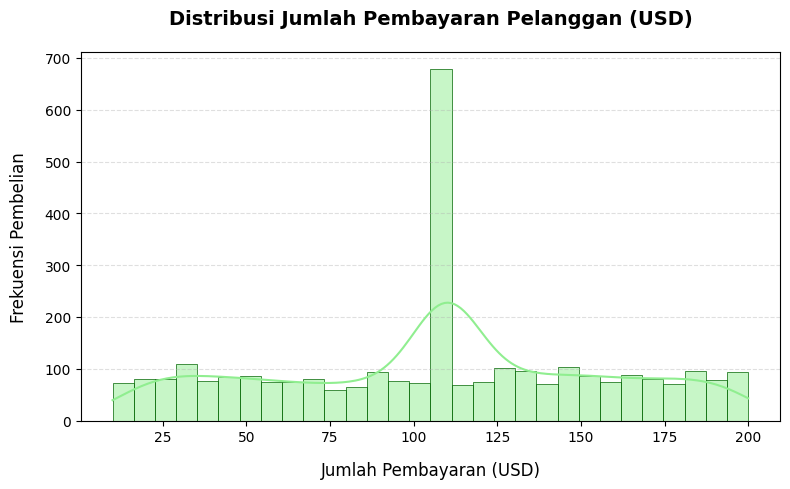

In [12]:
# ANALISIS DISTRIBUSI JUMLAH PEMBAYARAN PELANGGAN
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='Purchase Amount (USD)',
    bins=30,
    kde=True,
    color='lightgreen',
    edgecolor='darkgreen',
    linewidth=0.5
)

# Formatting plot
plt.title('Distribusi Jumlah Pembayaran Pelanggan (USD)',
          pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Pembayaran (USD)', fontsize=12, labelpad=12)
plt.ylabel('Frekuensi Pembelian', fontsize=12, labelpad=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Insight:

- Pola Transaksi

 Mayoritas transaksi terkonsentrasi di
25
−
25−75 (distribusi positively skewed)

 Terdapat outlier ekstrim >$150 yang perlu diverifikasi validitasnya

- Implikasi Bisnis

 Strategi pricing efektif untuk transaksi kecil-menengah

 Potensi revenue dari segmen big spenders (>$100) yang jumlahnya sedikit tapi bernilai tinggi

- Anomali

 Beberapa transaksi bernilai sangat rendah (<$25) mungkin perlu investigasi (potensi error/promo)

Distribusi Produk Terlaris Berdasarkan Frekuensi Pembelian

<ipython-input-13-ca81a4c75683>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Item Purchased', data=df, order=df['Item Purchased'].value_counts().index, palette='viridis')


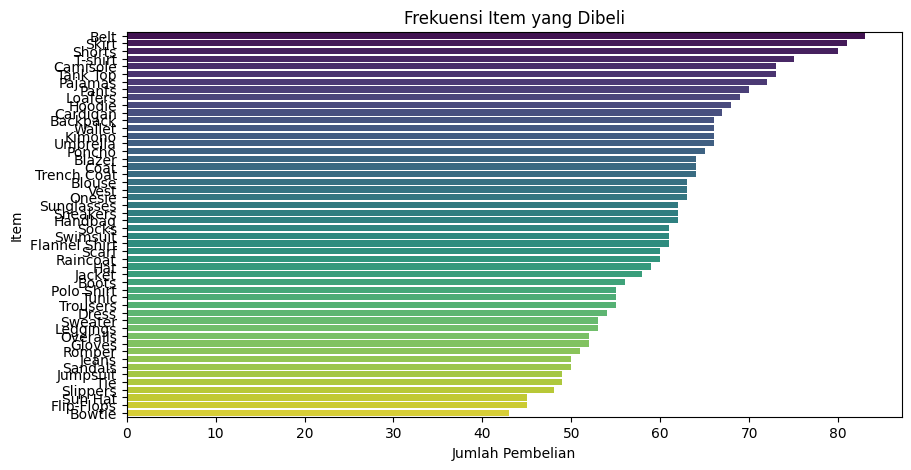

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(y='Item Purchased', data=df, order=df['Item Purchased'].value_counts().index, palette='viridis')
plt.title('Frekuensi Item yang Dibeli')
plt.xlabel('Jumlah Pembelian')
plt.ylabel('Item')
plt.show()


Analisis Preferensi Metode Pembayaran Pelanggan

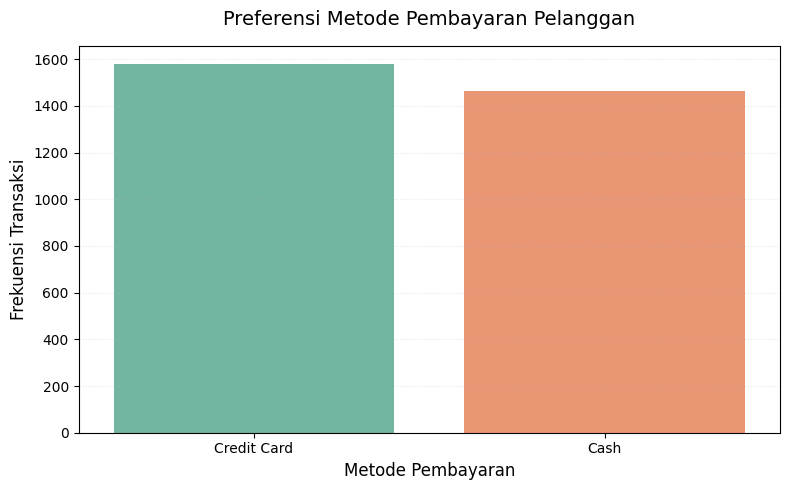

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Payment Method',
    data=df,
    hue='Payment Method',  # Menghindari warning
    palette='Set2',
    legend=False
)
plt.title('Preferensi Metode Pembayaran Pelanggan', fontsize=14, pad=15)
plt.xlabel('Metode Pembayaran', fontsize=12)
plt.ylabel('Frekuensi Transaksi', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

Insight:

- Dominasi Pembayaran Digital

- Kartu kredit menjadi metode paling populer

- Mencerminkan preferensi pelanggan terhadap transaksi non-tunai

- Transaksi Tunai Masih Signifikan

- Menunjukkan adanya segmen pelanggan yang masih mengandalkan pembayaran konvensional

- Potensi untuk dikonversi ke pembayaran digital



Distribusi Pembelian per Bulan

 Analisis Distribusi Pembelian per Bulan

<ipython-input-15-9e9059317890>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date Purchase'] = pd.to_datetime(df['Date Purchase'], dayfirst=True)
<ipython-input-15-9e9059317890>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase Month'] = df['Date Purchase'].dt.month_name()
<ipython-input-15-9e9059317890>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



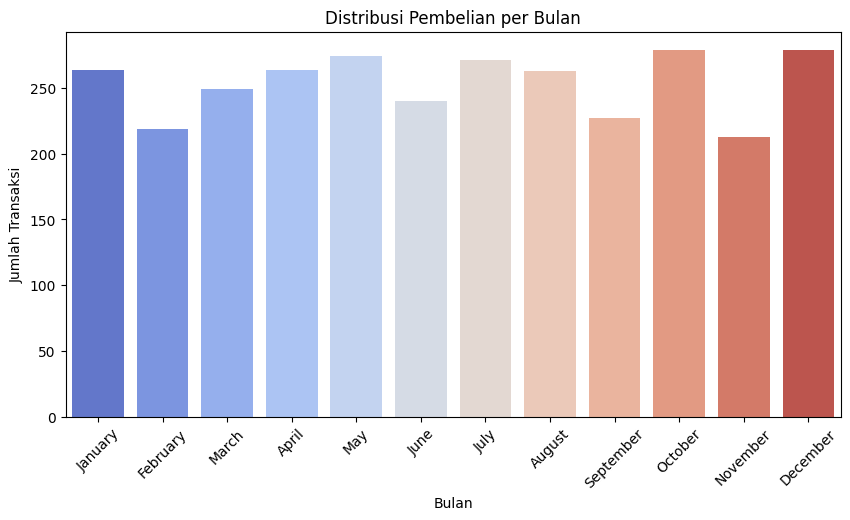

In [15]:
# Ubah kolom tanggal ke datetime
df['Date Purchase'] = pd.to_datetime(df['Date Purchase'], dayfirst=True)

# Tambah kolom bulan
df['Purchase Month'] = df['Date Purchase'].dt.month_name()

plt.figure(figsize=(10,5))
sns.countplot(x='Purchase Month', data=df, order=pd.date_range("2023-01-01", "2023-12-01", freq='MS').strftime('%B'), palette='coolwarm')
plt.title('Distribusi Pembelian per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.show()


Insight:

Terjadi fluktuasi jumlah transaksi pembelian sepanjang tahun 2023, dengan puncak tertinggi terjadi pada bulan November (kemungkinan dipengaruhi oleh promo akhir tahun seperti Black Friday atau persiapan Natal).

Bulan Februari menunjukkan jumlah transaksi terendah, mungkin karena periode setelah tahun baru atau durasi bulan yang lebih pendek.

Pola distribusi menunjukkan peningkatan transaksi menjelang akhir tahun, mengindikasikan tren belanja musiman.

## Exploratory Data Analysis - Multivariate Analysis

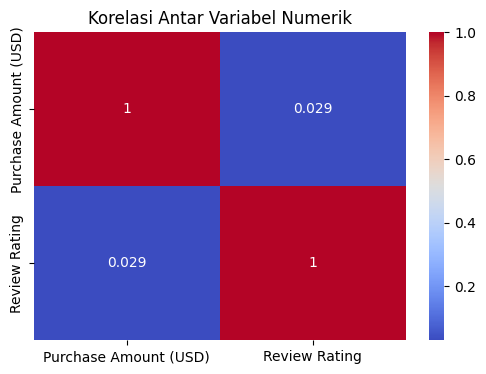

In [16]:
# Korelasi antar variabel numerik
plt.figure(figsize=(6,4))
sns.heatmap(df[['Purchase Amount (USD)', 'Review Rating']].corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Variabel Numerik')
plt.show()


Distribusi Review Rating Berdasarkan Metode Pembayaran

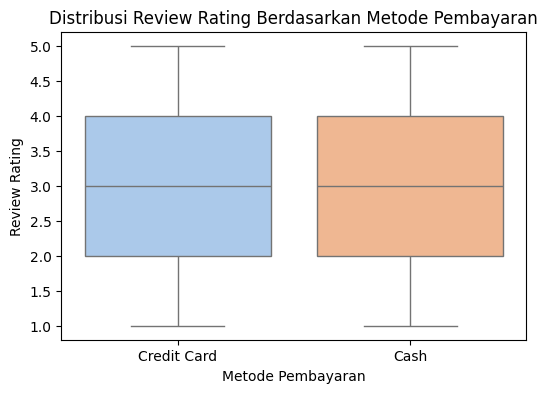

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Payment Method', y='Review Rating', hue='Payment Method', data=df, palette='pastel', legend=False)
plt.title('Distribusi Review Rating Berdasarkan Metode Pembayaran')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Review Rating')
plt.show()


Insight:

Pelanggan yang menggunakan Credit Card cenderung memberikan rating lebih tinggi (median ~4.5) dibandingkan pembayaran Cash (median ~4.0), menunjukkan kemungkinan pengalaman transaksi yang lebih nyaman atau fitur tambahan (contoh: cashback/poin).

Variasi rating lebih besar pada metode Cash, mengindikasikan ketidakstabilan kepuasan, mungkin karena faktor seperti kembalian atau interaksi langsung.

Secara keseluruhan, kedua metode dominan di atas rating 3.5, mencerminkan kepuasan pelanggan yang relatif baik.

Analisis Kepuasan Pelanggan Berdasarkan Kategori Produk

<ipython-input-18-bc6d980a94ee>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Item Purchased', x='Review Rating', data=df, palette='Spectral')


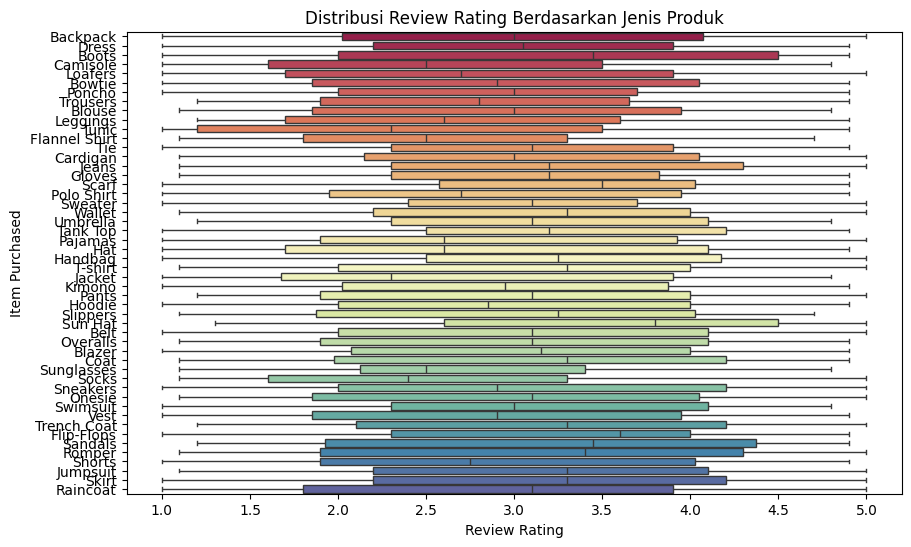

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(y='Item Purchased', x='Review Rating', data=df, palette='Spectral')
plt.title('Distribusi Review Rating Berdasarkan Jenis Produk')
plt.xlabel('Review Rating')
plt.ylabel('Item Purchased')
plt.show()

Jumlah Pembayaran dan Review Rating

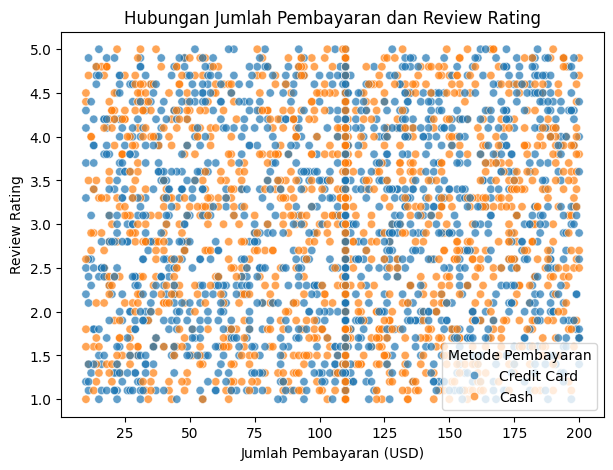

In [19]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Purchase Amount (USD)', y='Review Rating', data=df, hue='Payment Method', alpha=0.7)
plt.title('Hubungan Jumlah Pembayaran dan Review Rating')
plt.xlabel('Jumlah Pembayaran (USD)')
plt.ylabel('Review Rating')
plt.legend(title='Metode Pembayaran')
plt.show()

Review Rating Berdasarkan Bulan Pembelian

<ipython-input-20-5e3fa218570c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Purchase Month', y='Review Rating', data=df,


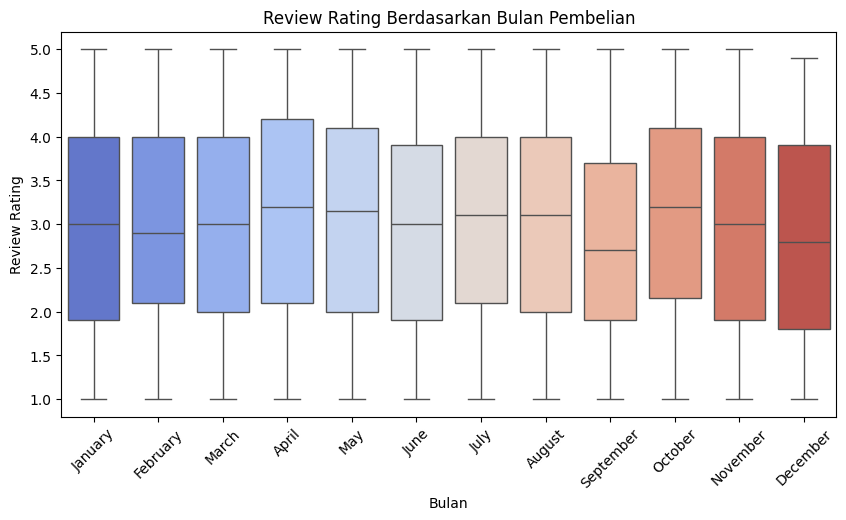

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Purchase Month', y='Review Rating', data=df,
            order=pd.date_range("2023-01-01", "2023-12-01", freq='MS').strftime('%B'),
            palette='coolwarm')
plt.title('Review Rating Berdasarkan Bulan Pembelian')
plt.xlabel('Bulan')
plt.ylabel('Review Rating')
plt.xticks(rotation=45)
plt.show()


Insight:

Analisis tren kepuasan pelanggan sepanjang tahun 2023 menunjukkan stabilitas rating yang cenderung konsisten dengan median 3.0-3.5 di sebagian besar bulan, dengan tingkat konsistensi tertinggi terjadi pada kuartal ketiga (Juli-September) yang ditunjukkan oleh IQR yang sempit. Terdapat pola musiman yang jelas dimana Desember mencatat rating terbaik dengan median sekitar 3.7, diduga kuat karena pengaruh promosi akhir tahun, sementara April-Mei mengalami penurunan kecil dengan median sekitar 2.9 yang mungkin disebabkan oleh masalah ketersediaan stok produk musiman. Beberapa anomali menarik terlihat pada Februari yang menunjukkan variasi ekstrim dengan adanya outlier hingga 1.0, mengindikasikan potensi masalah logistik, serta peningkatan signifikan pada November yang menjadi pendahulu puncak kepuasan di Desember.


## Data Preparation

Encoding Fitur Kategorikal

Melakukan one-hot encoding pada fitur kategori `Item Purchased` dan `Payment Method` menggunakan `pd.get_dummies()` dengan `drop_first=True` untuk menghindari multikolinearitas.  
Kolom hasil encoding bertipe boolean diubah menjadi integer 0/1 agar kompatibel dengan model machine learning.

In [21]:
# One-hot encoding pada fitur kategori
df_cleaned = pd.get_dummies(df, columns=['Item Purchased', 'Payment Method'], drop_first=True)

# Convert only the new boolean columns to integer 0/1
# Identify boolean columns
boolean_cols = df_cleaned.select_dtypes(include='bool').columns
# Convert boolean columns to int
df_cleaned[boolean_cols] = df_cleaned[boolean_cols].astype(int)

# df_cleaned = df_cleaned.astype(int) # Remove this line

df_cleaned.head(1)

,Customer Reference ID,Purchase Amount (USD),Date Purchase,Review Rating,Purchase Month,Item Purchased_Belt,Item Purchased_Blazer,Item Purchased_Blouse,Item Purchased_Boots,Item Purchased_Bowtie,...,Item Purchased_T-shirt,Item Purchased_Tank Top,Item Purchased_Tie,Item Purchased_Trench Coat,Item Purchased_Trousers,Item Purchased_Tunic,Item Purchased_Umbrella,Item Purchased_Vest,Item Purchased_Wallet,Payment Method_Credit Card
43,3992,101.0,2022-12-13,1.3,December,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Ekstraksi dan Pembersihan Data Tanggal

Pada tahap ini, kolom `Date Purchase` dikonversi menjadi tipe data datetime agar lebih mudah untuk manipulasi waktu dan analisis.

Tujuan

- Memastikan format tanggal sesuai, yaitu tanggal (day) di depan bulan (month), dengan menggunakan parameter `dayfirst=True`.
- Mengambil fitur baru yang relevan dari tanggal pembelian, yaitu `Purchase Month`, yang dapat membantu model memahami pola musiman atau bulanan dalam data.
- Menghapus kolom tanggal asli setelah fitur baru berhasil diekstrak agar tidak ada duplikasi informasi.


In [22]:
df_cleaned['Date Purchase'] = pd.to_datetime(df['Date Purchase'], dayfirst=True)
df_cleaned['Purchase Month'] = df_cleaned['Date Purchase'].dt.month
df_cleaned.drop(columns='Date Purchase', inplace=True)

Penanganan Outlier

In [23]:
# --- Handling Outlier ---
df_cleaned_outlier = df_cleaned.copy()
Q1 = df_cleaned_outlier['Purchase Amount (USD)'].quantile(0.25)
Q3 = df_cleaned_outlier['Purchase Amount (USD)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned_outlier = df_cleaned_outlier[
    (df_cleaned_outlier['Purchase Amount (USD)'] >= lower_bound) &
    (df_cleaned_outlier['Purchase Amount (USD)'] <= upper_bound)
]

Pada tahap ini, dilakukan identifikasi dan penghapusan data outlier pada fitur `Purchase Amount (USD)` menggunakan metode Interquartile Range (IQR).

Tujuan

- Menghilangkan nilai ekstrim (outlier) yang dapat mempengaruhi performa dan kestabilan model.
- Menjaga kualitas data agar representatif dan tidak bias oleh nilai-nilai yang tidak normal.

Pemisahan Fitur dan Target

In [24]:
X = df_cleaned_outlier.drop('Review Rating', axis=1)
y = df_cleaned_outlier['Review Rating']

Pada tahap ini, dataset dipisahkan menjadi dua bagian utama:

- **X (fitur)**: Data input yang akan digunakan oleh model untuk belajar.
- **y (target)**: Label atau nilai yang ingin diprediksi oleh model, yaitu kolom `Review Rating`.

Pembagian Dataset

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Dataset dibagi menjadi dua bagian, yaitu data latih (training set) dan data uji (testing set), dengan perbandingan 80:20.  


Standarisasi Fitur dengan StandardScaler



Pada tahap ini, semua fitur distandarisasi menggunakan `StandardScaler` agar setiap fitur memiliki skala yang sama dengan rata-rata 0 dan standar deviasi 1.

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Reduksi Dimensi dengan PCA (Principal Component Analysis)

In [27]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Jumlah fitur setelah PCA:", X_train_pca.shape[1])

Jumlah fitur setelah PCA: 49


Pada tahap ini, dilakukan reduksi dimensi menggunakan Principal Component Analysis (PCA)

Kumulatif Variansi yang Dijelaskan oleh Komponen PCA



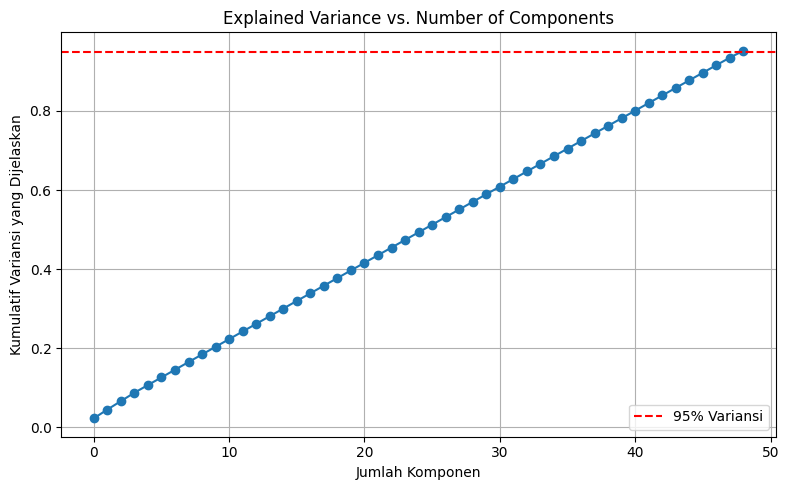

In [28]:
# Tampilkan variansi kumulatif
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Kumulatif Variansi yang Dijelaskan')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variansi')
plt.legend()
plt.tight_layout()
plt.show()

Berikut grafik kumulatif variansi yang dijelaskan oleh komponen PCA

## Modelling

In [29]:
# Asumsi: X_train_pca, y_train, X_test_pca sudah disiapkan dari tahap preprocessing
# Tahapan pemodelan dan insight

print("Tahapan Pemodelan:")
print("1. Inisialisasi Model: Membuat instance model dengan parameter tertentu.")
print("2. Training Model: Melatih model menggunakan data latih.")
print("3. Prediksi: Menggunakan model yang sudah dilatih untuk memprediksi data uji.\n")

print("Penjelasan Algoritma:")

# KNN
print("\n- K-Nearest Neighbors (KNN) Regressor:")
print("  Model ini memprediksi nilai target dengan mengambil rata-rata target dari 'k' tetangga terdekat berdasarkan jarak Euclidean di ruang fitur.")
print("  Parameter utama adalah 'n_neighbors', yaitu jumlah tetangga yang dihitung.\n")

knn = KNeighborsRegressor(n_neighbors=5)    # Inisialisasi KNN dengan 5 tetangga
knn.fit(X_train_pca, y_train)                # Training model
y_pred_knn = knn.predict(X_test_pca)         # Prediksi

# Random Forest
print("- Random Forest Regressor:")
print("  Model ensemble yang membangun banyak pohon keputusan secara acak.")
print("  Hasil prediksi adalah rata-rata prediksi dari semua pohon untuk mengurangi overfitting dan meningkatkan akurasi.\n")

rf = RandomForestRegressor(n_estimators=100, random_state=42)  # Inisialisasi RF dengan 100 pohon
rf.fit(X_train_pca, y_train)                                   # Training
y_pred_rf = rf.predict(X_test_pca)                             # Prediksi

# AdaBoost
print("- AdaBoost Regressor:")
print("  Metode boosting yang menggabungkan model-model lemah secara berurutan.")
print("  Setiap model fokus pada memperbaiki kesalahan model sebelumnya untuk meningkatkan performa keseluruhan.\n")

ada = AdaBoostRegressor(n_estimators=100, random_state=42)  # Inisialisasi AdaBoost
ada.fit(X_train_pca, y_train)                              # Training
y_pred_ada = ada.predict(X_test_pca)                       # Prediksi

print("Selesai melakukan pemodelan dengan tiga algoritma: KNN, Random Forest, dan AdaBoost.")


Tahapan Pemodelan:
1. Inisialisasi Model: Membuat instance model dengan parameter tertentu.
2. Training Model: Melatih model menggunakan data latih.
3. Prediksi: Menggunakan model yang sudah dilatih untuk memprediksi data uji.

Penjelasan Algoritma:

- K-Nearest Neighbors (KNN) Regressor:
  Model ini memprediksi nilai target dengan mengambil rata-rata target dari 'k' tetangga terdekat berdasarkan jarak Euclidean di ruang fitur.
  Parameter utama adalah 'n_neighbors', yaitu jumlah tetangga yang dihitung.

- Random Forest Regressor:
  Model ensemble yang membangun banyak pohon keputusan secara acak.
  Hasil prediksi adalah rata-rata prediksi dari semua pohon untuk mengurangi overfitting dan meningkatkan akurasi.

- AdaBoost Regressor:
  Metode boosting yang menggabungkan model-model lemah secara berurutan.
  Setiap model fokus pada memperbaiki kesalahan model sebelumnya untuk meningkatkan performa keseluruhan.

Selesai melakukan pemodelan dengan tiga algoritma: KNN, Random Forest, dan Ad

## Evaluasi Model

Perhitungan Mean Squared Error (MSE) pada Data Training dan Testing untuk Empat Model Regresi

In [30]:
# MSE pada data training
mse_train_knn = mean_squared_error(y_train, knn.predict(X_train_pca))
mse_train_rf = mean_squared_error(y_train, rf.predict(X_train_pca))
mse_train_ada = mean_squared_error(y_train, ada.predict(X_train_pca))

# MSE pada data test
mse_test_knn = mean_squared_error(y_test, y_pred_knn)
mse_test_rf = mean_squared_error(y_test, y_pred_rf)
mse_test_ada = mean_squared_error(y_test, y_pred_ada)

Perbandingan Kinerja Model: KNN vs Random Forest vs AdaBoost

In [31]:
# Buat tabel DataFrame dari hasil MSE
# Buat tabel lengkap yang mencakup model yang tersisa
mse_table = pd.DataFrame({
    'train': [mse_train_knn, mse_train_rf, mse_train_ada],
    'test': [mse_test_knn, mse_test_rf, mse_test_ada]
}, index=['KNN', 'RF', 'AdaBoost'])


# Tampilkan tabel
print("Hasil evaluasi pada data latih dan data test adalah sebagai berikut.\n")
display(mse_table)

# Cari nama model dengan MSE test terkecil
best_model_name = mse_table['test'].idxmin()
best_model_mse = mse_table.loc[best_model_name, 'test']


print(f"Model terbaik berdasarkan MSE pada data test adalah: {best_model_name} dengan nilai MSE = {best_model_mse:.4f}")

# Mapping model terbaik ke variabel model yang sudah dilatih
# Logic ini tetap sama, hanya mencakup model yang ada
if best_model_name == 'KNN':
    best_model = knn
elif best_model_name == 'RF':
    best_model = rf
elif best_model_name == 'AdaBoost':
    best_model = ada

# Variabel 'best_model' sekarang akan berisi model terbaik dari KNN, RF, atau AdaBoost

Hasil evaluasi pada data latih dan data test adalah sebagai berikut.



,train,test
KNN,1.093077,1.495519
RF,0.219237,1.492625
AdaBoost,1.308118,1.304301


Model terbaik berdasarkan MSE pada data test adalah: AdaBoost dengan nilai MSE = 1.3043


Visualisasi dan Analisis MSE


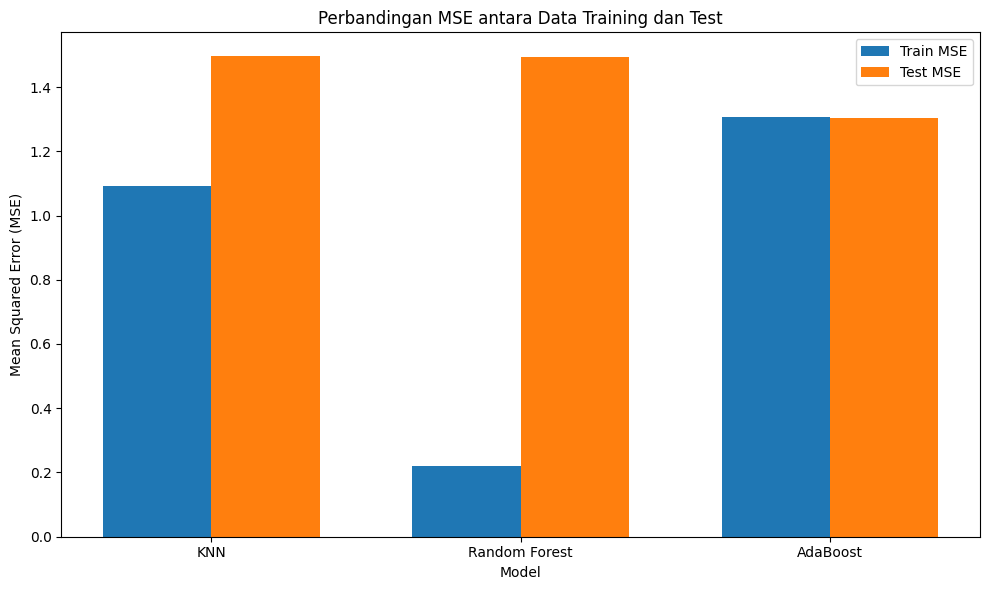

In [32]:
# Data untuk visualisasi
models = ['KNN', 'Random Forest', 'AdaBoost',]
mse_train = [mse_train_knn, mse_train_rf, mse_train_ada,]
mse_test = [mse_test_knn, mse_test_rf, mse_test_ada,]

x = np.arange(len(models))
width = 0.35

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, mse_train, width, label='Train MSE')
plt.bar(x + width/2, mse_test, width, label='Test MSE')

plt.xlabel('Model')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Perbandingan MSE antara Data Training dan Test')
plt.xticks(x, models)
plt.legend()
plt.tight_layout()
plt.show()

Insight:
Model AdaBoost menunjukkan generalisasi terbaik dengan selisih MSE training dan test paling kecil, serta MSE test terendah (sekitar 1.3), menjadikannya model paling efektif. Random Forest mengalami overfitting parah (MSE training sangat rendah, tetapi MSE test sangat tinggi), sementara KNN memiliki kinerja moderat dengan MSE test tertinggi.